## Моделирование эксперимента для O2-O2 из эксперимента Stimulated Raman scattering measurements of V–V transfer in oxygen Tai Ahn, Igor Adamovich, Walter R. Lempert

In [2]:
from pathlib import Path
from io import StringIO
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

# ========== ВЫБОР МЕТОДА УЧЁТА ДИФФУЗИИ ==========
METHOD = "method_of_lines"   # "none", "analytic_factor", "method_of_lines"
# =================================================

BASE_DIR = Path('.').resolve()
PARTICLE_A, PARTICLE_B = "O2", "O2"
REGRESSION_COEFFS_PATH = BASE_DIR / f"{PARTICLE_A}_{PARTICLE_B}_regression_coefs.csv"

x_exp_v_0 = [0.10761589403973511, 0.15728476821192056, 0.24006622516556292, 0.2897350993377484, 0.3394039735099338, 0.4884105960264901, 0.4221854304635762, 0.6291390728476822, 0.7119205298013246, 0.8857615894039735, 1.001655629139073, 1.109271523178808, 1.3410596026490067, 1.2251655629139073, 1.6142384105960266, 1.9867549668874174, 2.218543046357616, 2.599337748344371, 3.80794701986755, 5.091059602649007, 6.357615894039736]
y_exp_v_0 = [0.628772378516624, 0.641304347826087, 0.6505115089514066, 0.6530690537084399, 0.6650895140664962, 0.6684143222506393, 0.6769820971867008, 0.6782608695652174, 0.6962915601023018, 0.6982097186700766, 0.708695652173913, 0.7109974424552429, 0.7175191815856776, 0.7234015345268542, 0.7250639386189257, 0.7313299232736572, 0.7329923273657288, 0.7393861892583119, 0.7421994884910484, 0.7558823529411763, 0.7608695652173911]
x_exp_v_1 = [0.13929618768328447, 0.17595307917888564, 0.2272727272727273, 0.26392961876832843, 0.30058651026392963, 0.44721407624633436, 0.37390029325513197, 0.5278592375366569, 0.6085043988269795, 0.7331378299120235, 0.9237536656891496, 0.8211143695014663, 1.121700879765396, 1.0263929618768328, 1.341642228739003, 1.620234604105572, 1.8548387096774195, 2.140762463343109, 3.1231671554252203, 4.142228739002933, 5.161290322580646, 10.109970674486805]
y_exp_v_1 = [0.3424731182795699, 0.3173118279569892, 0.30741935483870964, 0.29666666666666663, 0.2839784946236559, 0.2740860215053763, 0.2725806451612903, 0.2579569892473118, 0.23666666666666666, 0.22935483870967743, 0.22268817204301075, 0.21989247311827956, 0.2110752688172043, 0.20397849462365591, 0.20032258064516129, 0.19559139784946236, 0.19043010752688172, 0.19043010752688172, 0.18913978494623657, 0.17537634408602149, 0.17172043010752688, 0.16913978494623655]
x_exp_v_2 = [0.10916179337231968, 0.15204678362573099, 0.21442495126705652, 0.2573099415204678, 0.36257309941520466, 0.30409356725146197, 0.39766081871345027, 0.5107212475633528, 0.6003898635477583, 0.7134502923976608, 0.8070175438596491, 1.009746588693957, 0.9083820662768031, 1.0916179337231968, 1.2982456140350878, 1.6101364522417154, 1.793372319688109, 2.1052631578947367, 3.0994152046783623, 4.085769980506822, 5.115009746588694]
y_exp_v_2 = [0.025, 0.027931034482758618, 0.03021551724137931, 0.03564655172413793, 0.03646551724137931, 0.0368103448275862, 0.0421551724137931, 0.04603448275862069, 0.04741379310344827, 0.04831896551724138, 0.049094827586206896, 0.0484051724137931, 0.04642241379310345, 0.04491379310344828, 0.0496551724137931, 0.048663793103448275, 0.048362068965517244, 0.044655172413793104, 0.043448275862068966, 0.040948275862068964, 0.03995689655172414]
x_exp_v_3 = [0.21052631578947367, 0.1117078410311493, 0.16326530612244897, 0.2749731471535983, 0.37379162191192267, 0.32223415682062295, 0.41675617615467236, 0.5026852846401718, 0.6229860365198711, 0.9151450053705693, 0.8206229860365198, 1.0053705692803436, 0.7132116004296455, 1.117078410311493, 1.2975295381310419, 1.6197636949516647, 1.8045112781954886, 2.1052631578947367, 3.1106337271750806, 4.116004296455424, 5.138560687432868]
y_exp_v_3 = [0.0020372670807453416, 0.0030683229813664595, 0.0038633540372670807, 0.004186335403726708, 0.004, 0.004931677018633541, 0.0063229813664596275, 0.00791304347826087, 0.00982608695652174, 0.009962732919254659, 0.011006211180124223, 0.012198757763975155, 0.012335403726708074, 0.014521739130434783, 0.013726708074534162, 0.01253416149068323, 0.014248447204968944, 0.01306832298136646, 0.013006211180124223, 0.01329192546583851, 0.012608695652173913]
x_exp_v_4 = [0.16371681415929204, 0.3185840707964602, 0.415929203539823, 0.2079646017699115, 0.11061946902654868, 0.2654867256637168, 0.37168141592920356, 0.5176991150442478, 0.8893805309734513, 0.6017699115044248, 0.8053097345132744, 1, 0.6946902654867256, 1.2964601769911503, 1.592920353982301, 1.092920353982301, 1.7964601769911503, 2.0973451327433628, 3.0929203539823007, 4.097345132743363, 5.123893805309734]
y_exp_v_4 = [0.0004791666666666667, 0.0008697916666666667, 0.00109375, 0.0011510416666666667, 0.0012760416666666666, 0.0016875, 0.0015416666666666667, 0.0016510416666666665, 0.0018124999999999999, 0.0020677083333333333, 0.002390625, 0.0030729166666666665, 0.0038125, 0.0037760416666666667, 0.0037447916666666667, 0.0044531250000000005, 0.0048020833333333336, 0.004541666666666666, 0.0036249999999999998, 0.00459375, 0.004973958333333333]
x_exp_v_5 = [0.6129032258064516, 1.3118279569892473, 1.6093189964157706, 1.8136200716845878, 2.111111111111111, 3.111111111111111, 4.111111111111111]
y_exp_v_5 = [0.00021613691931540344, 0.0006518337408312959, 0.000656234718826406, 0.0006034229828850857, 0.0011212713936430319, 0.0011095354523227385, 0.001721271393643032]

# Погрешности эксперимента: ye — по доле популяции, xe — по времени (мкс). None = не рисовать «усы» по оси.
# Длина списка = числу точек; можно задать одно число — одинаковая погрешность для всех точек.
ye_exp_v_0 = [0.010025380710659837] * len(y_exp_v_0)
ye_exp_v_1 = [0.010173160173160167] * len(y_exp_v_1)
ye_exp_v_2 = [0.004945770065075926] * len(y_exp_v_2)
ye_exp_v_3 = [0.0014414784394250514] * len(y_exp_v_3)
ye_exp_v_4 = [0.001025773195876289] * len(y_exp_v_4)
ye_exp_v_5 = [0.0005017114914425429] * len(y_exp_v_5)

xe_exp_v_0 = None
xe_exp_v_1 = None
xe_exp_v_2 = None
xe_exp_v_3 = None
xe_exp_v_4 = None
xe_exp_v_5 = None

exp_o2_ahn_inline = [
    (x_exp_v_0, y_exp_v_0, ye_exp_v_0, xe_exp_v_0),
    (x_exp_v_1, y_exp_v_1, ye_exp_v_1, xe_exp_v_1),
    (x_exp_v_2, y_exp_v_2, ye_exp_v_2, xe_exp_v_2),
    (x_exp_v_3, y_exp_v_3, ye_exp_v_3, xe_exp_v_3),
    (x_exp_v_4, y_exp_v_4, ye_exp_v_4, xe_exp_v_4),
    (x_exp_v_5, y_exp_v_5, ye_exp_v_5, xe_exp_v_5),
]

# ... (функции coeffs_dict_from_regression_csv, k_lookup, R_VV_fast, read_csv_with_comma_fix, load_experimental_data) остаются без изменений ...
# Они приведены ниже для полноты кода

def coeffs_dict_from_regression_csv(path: Path):
    df = pd.read_csv(path)
    a_cols = sorted(
        (c for c in df.columns if c.startswith("a_")),
        key=lambda s: int(s.split("_")[1]),
    )
    out = {}
    for _, row in df.iterrows():
        key = "_".join(str(int(row[c])) for c in ("i1", "f1", "i2", "f2"))
        coeffs = []
        for cname in a_cols:
            val = row[cname]
            if pd.isna(val):
                continue
            coeffs.append(float(val))
        out[key] = coeffs
    return out

if REGRESSION_COEFFS_PATH.exists():
    COEFFS = coeffs_dict_from_regression_csv(REGRESSION_COEFFS_PATH)
    print(f"k_VV: {REGRESSION_COEFFS_PATH.name} ({len(COEFFS)} переходов)")
else:
    with open(BASE_DIR / "coeffs_sparse2.json", "r") as f:
        COEFFS = json.load(f)
    print("k_VV: fallback coeffs_sparse2.json")

def k_lookup(coeffs_dict, i1, f1, i2, f2, T, rate_multiplier=1.0):
    key = f"{i1}_{f1}_{i2}_{f2}"
    coeffs = coeffs_dict.get(key)
    if coeffs is None:
        return 0.0
    x = T ** (-1/3)
    return rate_multiplier * np.exp(sum(c * x ** i for i, c in enumerate(coeffs)))

def R_VV_fast(v, N, v_max, T, coeffs=COEFFS, rate_multiplier=1.0):
    R = 0.0
    for v_ in range(v_max + 1):
        k1 = k2 = k3 = k4 = 0.0
        if v + 1 <= v_max and v_ + 1 <= v_max:
            k1 = k_lookup(coeffs, i1=v_, i2=v+1, f1=v_+1, f2=v, T=T, rate_multiplier=rate_multiplier)
        if v - 1 >= 0 and v_ - 1 >= 0:
            k2 = k_lookup(coeffs, i1=v_, f1=v_-1, i2=v-1, f2=v, T=T, rate_multiplier=rate_multiplier)
        if v - 1 >= 0 and v_ + 1 <= v_max:
            k3 = k_lookup(coeffs, i1=v_, f1=v_+1, i2=v, f2=v-1, T=T, rate_multiplier=rate_multiplier)
        if v + 1 <= v_max and v_ - 1 >= 0:
            k4 = k_lookup(coeffs, i1=v_, f1=v_-1, i2=v, f2=v+1, T=T, rate_multiplier=rate_multiplier)
        Nvp1 = N[v+1] if v+1 <= v_max else 0.0
        Nvm1 = N[v-1] if v-1 >= 0 else 0.0
        R += (k1 * Nvp1 + k2 * Nvm1 - (k3 + k4) * N[v]) * N[v_]
    return R

def read_csv_with_comma_fix(filename, sep=";"):
    with open(BASE_DIR / filename, "r", encoding="utf-8") as f:
        content = f.read()
    return pd.read_csv(StringIO(content.replace(",", ".")), sep=sep, header=None)

def load_experimental_data(v_max):
    exp_data = {"solid": [], "dashed": []}
    for v in range(v_max + 1):
        exp_data["solid"].append(read_csv_with_comma_fix(f"v{v}solid.csv"))
        exp_data["dashed"].append(read_csv_with_comma_fix(f"v{v}dashed.csv"))
    return exp_data

# ========== ФИЗИЧЕСКИЕ ПАРАМЕТРЫ ==========
t_span = (0, 12e-6)
t_eval = np.linspace(0, 12e-6, 600)
T = 300
V_MAX = 5
N_TOTAL = 5.07e18               # см^-3

initial_fractions = np.zeros(V_MAX + 1)
initial_fractions[0] = 0.63
initial_fractions[1] = 0.37

# mult = 3 gives better results
mult = 1
rate_multipliers = {
    "solid": 1 * mult,
    "dashed": 8 * mult
}

# Параметры гауссовых пучков (одинаковые для простоты)
sigma_pump_cm = 80e-4    # 46 мкм
sigma_probe_cm = 40e-4

# Коэффициент самодиффузии N2 при 760 Торр, 300 K (см^2/с)
D_N2 = 0.2                # типичное значение для N2
P_torr = 760
D = D_N2 * (760.0 / P_torr)

# ========== ПОСТРОЕНИЕ НАЧАЛЬНОГО РАСПРЕДЕЛЕНИЯ ДЛЯ МЕТОДА ПРЯМЫХ ==========
def build_initial_state_method_of_lines(N_r, R_max):
    """Создаёт начальное состояние для метода прямых: массив (V_MAX+1, N_r)."""
    dr = R_max / (N_r - 1)
    r = np.linspace(0, R_max, N_r)
    # Гауссов профиль возбуждения: n_1(r) ~ exp(-2 r^2 / sigma_pump^2)
    profile = np.exp(-2.0 * r**2 / sigma_pump_cm**2)
    # Амплитуда такой, чтобы после усреднения с пробным пучком (sigma_probe)
    # получалась f1 = initial_fractions[1]
    # Веса пробного пучка: w_probe = r * exp(-2 r^2 / sigma_probe^2) (потом нормировка)
    w_probe = r * np.exp(-2.0 * r**2 / sigma_probe_cm**2)
    # Нормировочный интеграл для полной концентрации
    integral_total = np.trapz(N_TOTAL * w_probe, r)
    integral_profile = np.trapz(profile * w_probe, r)
    # Усреднённая доля = A * integral_profile / integral_total, где A - амплитуда profile
    A = (initial_fractions[1] * integral_total) / integral_profile
    n1_init = A * profile
    n0_init = N_TOTAL - n1_init
    # Собираем матрицу (V_MAX+1, N_r)
    state = np.zeros((V_MAX + 1, N_r))
    state[0, :] = n0_init
    state[1, :] = n1_init
    return state, r, dr

def laplacian_cyl(f, r, dr):
    """Дискретный оператор Лапласа в цилиндр. координатах для равномерной сетки.
       f: 1D массив значений в узлах r. Возвращает массив той же формы.
       Граничные условия: симметрия при r=0 (df/dr=0), f=0 на внешней границе.
    """
    N = len(r)
    lap = np.zeros_like(f)
    # Внутренние узлы (индексы 1..N-2)
    for i in range(1, N-1):
        ri = r[i]
        # Половинные индексы
        r_plus  = ri + 0.5*dr
        r_minus = ri - 0.5*dr
        lap[i] = (1.0/ri) * ( (r_plus * (f[i+1] - f[i]) - r_minus * (f[i] - f[i-1])) / dr**2 )
    # Узел на оси (i=0)
    lap[0] = 4.0 * (f[1] - f[0]) / dr**2
    # Внешняя граница (i=N-1) – фиксировано f=0, поэтому лапласиан можно не считать,
    # но для порядка оставим как линейную экстраполяцию:
    lap[-1] = 0.0   # т.к. условие f=0, всё равно решение не войдёт в эту область
    return lap

# ========== ПРАВАЯ ЧАСТЬ ДЛЯ МЕТОДА ПРЯМЫХ ==========
def rhs_method_of_lines(t, state_flat, v_max, N_r, r, dr, T, D, rate_multiplier):
    """state_flat упакован как: сначала все r для v=0, потом v=1, и т.д."""
    state = state_flat.reshape((v_max+1, N_r))   # (v_max+1) x N_r
    dstate = np.zeros_like(state)

    # Лапласианы для v>0
    laplacians = np.zeros((v_max+1, N_r))
    for v in range(1, v_max+1):
        laplacians[v, :] = laplacian_cyl(state[v, :], r, dr)
    # Сумма лапласианов возбуждённых уровней для компенсации в v=0
    sum_lapl_positive = np.sum(laplacians[1:, :], axis=0)   # по всем v>0

    # Для каждого радиального узла вычисляем VV-кинетику
    for i in range(N_r):
        local_N = state[:, i]   # вектор концентраций по v в узле i
        # V-V член для каждого уровня
        for v in range(v_max+1):
            dstate[v, i] = R_VV_fast(v, local_N, v_max, T, rate_multiplier=rate_multiplier)

    # Добавляем диффузию: для v>0 прибавляем D*laplacian, для v=0 вычитаем D*sum_lapl_positive
    for v in range(1, v_max+1):
        dstate[v, :] += D * laplacians[v, :]
    dstate[0, :] -= D * sum_lapl_positive

    return dstate.flatten()

def spatial_average(state, r, dr, sigma_probe):
    """Усреднение концентраций по гауссову пробному объёму."""
    # Весовая функция: r * exp(-2 r^2 / sigma_probe^2)
    w = r * np.exp(-2.0 * r**2 / sigma_probe**2)
    norm = np.trapz(w, r)
    w_norm = w / norm
    avg = np.trapz(state * w_norm[np.newaxis, :], r, axis=1)
    return avg   # массив длиной v_max+1

# ========== УНИВЕРСАЛЬНАЯ ФУНКЦИЯ РЕШЕНИЯ ==========
def solve_for_rate_multiplier(initial_fractions, rate_multiplier, method="none"):
    """
    method : "none" – без диффузии
             "analytic_factor" – аналитический фактор
             "method_of_lines" – метод прямых
    """
    if method in ("none", "analytic_factor"):
        # Однородная начальная концентрация (как раньше)
        N_init = initial_fractions * N_TOTAL
        sol = solve_ivp(
            lambda t, N: rhs_time(t, N, V_MAX, T, rate_multiplier),
            t_span,
            N_init,
            t_eval=t_eval,
            method="Radau",
        )
        if not sol.success:
            raise RuntimeError(f"solve_ivp failed: {sol.message}")
        if method == "analytic_factor":
            # Аналитический фактор
            R = 1.0 / np.sqrt(1.0 + 4.0 * D * sol.t / (sigma_pump_cm**2 + sigma_probe_cm**2))
            N_corrected = sol.y * R[np.newaxis, :]
            fractional = N_corrected / N_TOTAL
        else:
            fractional = sol.y / np.sum(sol.y, axis=0)
        return sol, fractional

    elif method == "method_of_lines":
        # Параметры сетки
        R_max = 200e-4   # 200 мкм
        N_r = 80
        dr = R_max / (N_r - 1)
        r = np.linspace(0, R_max, N_r)

        # Начальное пространственное распределение
        state_init, r, dr = build_initial_state_method_of_lines(N_r, R_max)
        state_flat = state_init.flatten()

        sol = solve_ivp(
            lambda t, y: rhs_method_of_lines(t, y, V_MAX, N_r, r, dr, T, D, rate_multiplier),
            t_span,
            state_flat,
            t_eval=t_eval,
            method="Radau",
            rtol=1e-9,
            atol=1e6,
        )
        if not sol.success:
            raise RuntimeError(f"solve_ivp failed: {sol.message}")

        # Усреднение по пробному объёму для каждого момента времени
        n_t_avg = np.zeros((V_MAX+1, len(sol.t)))
        for idx, t in enumerate(sol.t):
            state_t = sol.y[:, idx].reshape((V_MAX+1, N_r))
            n_t_avg[:, idx] = spatial_average(state_t, r, dr, sigma_probe_cm)
        fractional = n_t_avg / N_TOTAL   # доли от полной концентрации
        return sol, fractional

    else:
        raise ValueError("Неизвестный метод")

# Старая rhs_time (для методов без пространственной сетки)
def rhs_time(t, N, v_max, T, rate_multiplier):
    dNdt = np.zeros_like(N)
    for v in range(v_max + 1):
        dNdt[v] = R_VV_fast(v, N, v_max, T, rate_multiplier=rate_multiplier)
    return dNdt

# Загрузка экспериментальных данных
exp_data = load_experimental_data(V_MAX)

# ========== РАСЧЁТ ДЛЯ ВСЕХ МЕТОДОВ ==========
simulations = {}
for style, mult_val in rate_multipliers.items():
    simulations[style] = {}
    for method in ["none", "analytic_factor", "method_of_lines"]:
        sol, frac = solve_for_rate_multiplier(initial_fractions, mult_val, method=method)
        simulations[style][method] = {"sol": sol, "fractional": frac}


k_VV: O2_O2_regression_coefs.csv (72 переходов)


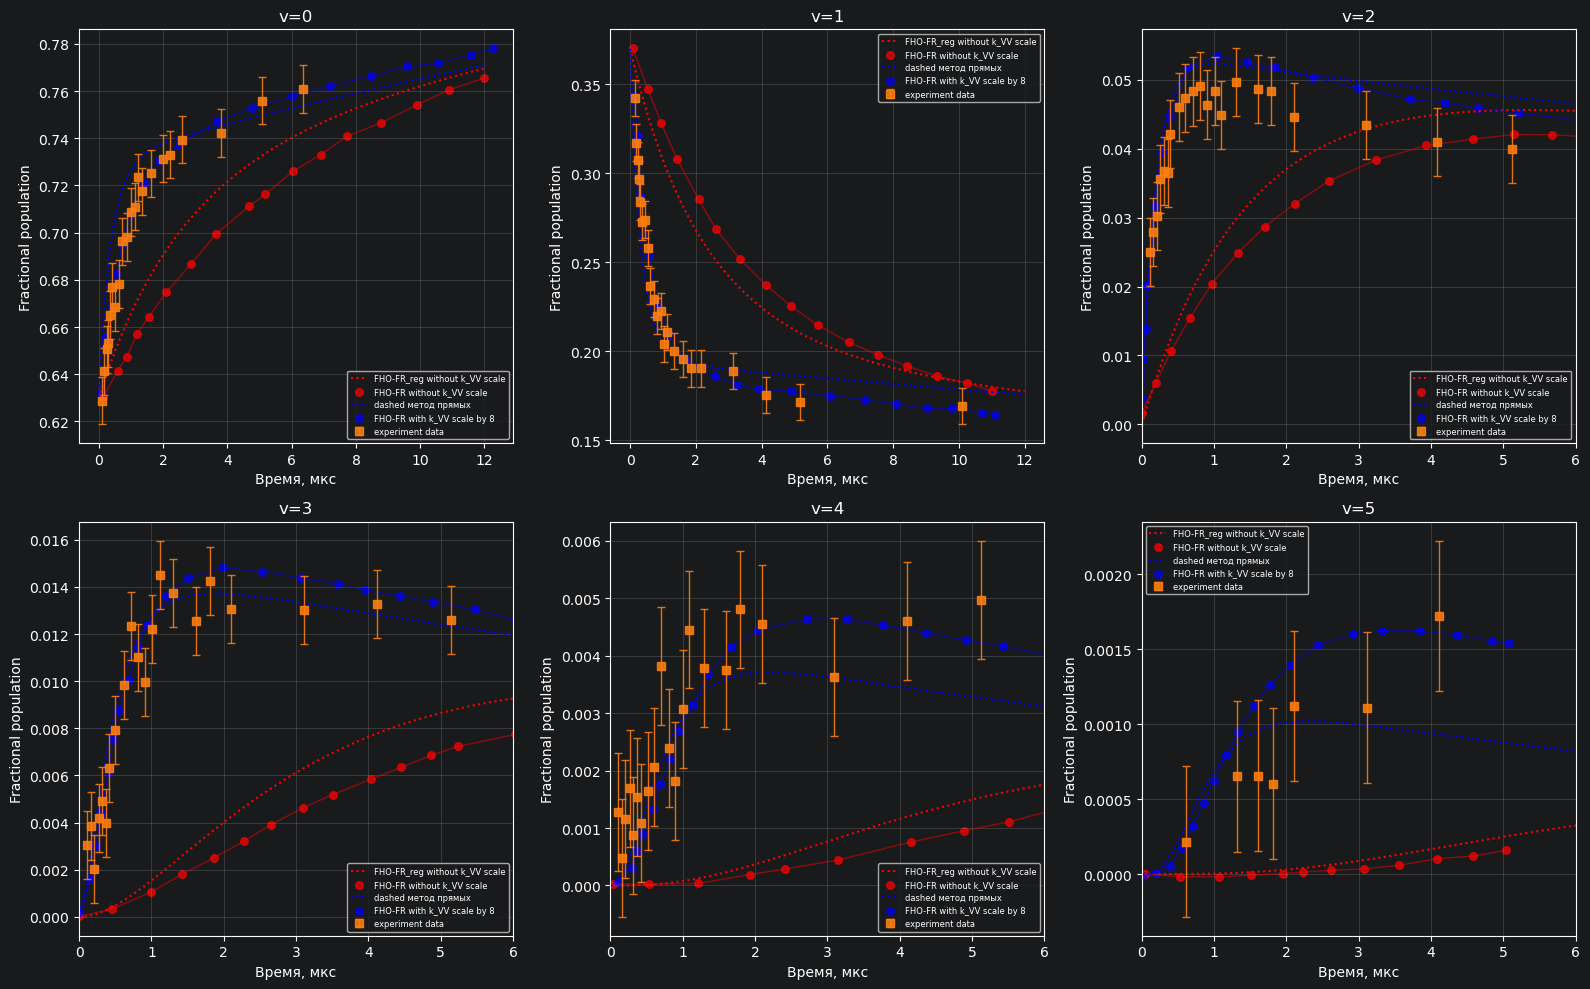


=== Результаты для метода 'method_of_lines' ===

--- solid: k_VV x 1 ---
t = 0.00 мкс:
  v=0: 0.630000
  v=1: 0.370000
  v=2: 0.000000
  v=3: 0.000000
  v=4: 0.000000
  v=5: 0.000000
t = 1.20 мкс:
  v=0: 0.671471
  v=1: 0.298025
  v=2: 0.028342
  v=3: 0.002035
  v=4: 0.000121
  v=5: 0.000006
t = 2.40 мкс:
  v=0: 0.698353
  v=1: 0.256367
  v=2: 0.039776
  v=3: 0.004931
  v=4: 0.000523
  v=5: 0.000050
t = 6.01 мкс:
  v=0: 0.740257
  v=1: 0.202889
  v=2: 0.045501
  v=3: 0.009273
  v=4: 0.001756
  v=5: 0.000324
t = 12.00 мкс:
  v=0: 0.769560
  v=1: 0.177527
  v=2: 0.040906
  v=3: 0.009381
  v=4: 0.002137
  v=5: 0.000488

--- dashed: k_VV x 8 ---
t = 0.00 мкс:
  v=0: 0.630000
  v=1: 0.370000
  v=2: 0.000000
  v=3: 0.000000
  v=4: 0.000000
  v=5: 0.000000
t = 1.20 мкс:
  v=0: 0.730402
  v=1: 0.200065
  v=2: 0.052227
  v=3: 0.013226
  v=4: 0.003270
  v=5: 0.000811
t = 2.40 мкс:
  v=0: 0.739917
  v=1: 0.191176
  v=2: 0.050584
  v=3: 0.013603
  v=4: 0.003702
  v=5: 0.001018
t = 6.01 мкс:
  v=0

In [3]:
# ========== ГРАФИКИ (сравнение методов для одного стиля) ==========

def _err_for_plot(err_spec, n_pts, axis_hint=""):
    """None или все нули — без ошибок по оси. Скаляр или последовательность длины n_pts."""
    if err_spec is None:
        return None
    arr = np.atleast_1d(np.asarray(err_spec, dtype=float)).ravel()
    if arr.size == 1:
        v = float(arr[0])
        return None if v == 0.0 else v
    if arr.size != n_pts:
        raise ValueError(f"погрешность{axis_hint}: нужна длина 1 или {n_pts}, сейчас {arr.size}")
    return None if np.all(arr == 0) else arr


plot_styles = {
    "solid": {"color": "red", "exp_color": "red"},
    "dashed": {"color": "blue", "exp_color": "blue"},
}
method_labels = {
    "none": "без дифф.",
    "analytic_factor": "аналит. фактор",
    "method_of_lines": "метод прямых",
}
method_linestyles = {"none": "-", "analytic_factor": "--", "method_of_lines": ":"}

# Кастомные подписи легенды (пустые словари / None — как раньше).
# LEGEND_SIM: ключ (style, method), например ("solid", "method_of_lines").
LEGEND_SIM = {("solid", "method_of_lines"): "FHO-FR_reg without k_VV scale",
              ("dashed", "none"): "FHO-FR_reg with k_VV scale by 8",}
LEGEND_EXP_ARTICLE = {"solid": "FHO-FR without k_VV scale",
                      "dashed": "FHO-FR with k_VV scale by 8"}
LEGEND_EXP_INLINE = "experiment data"


def _legend_sim(style, method):
    return LEGEND_SIM.get((style, method), f"{style} {method_labels[method]}")


def _legend_exp_article(style):
    return LEGEND_EXP_ARTICLE.get(style, f"статья ({style})")


def _legend_exp_inline():
    return LEGEND_EXP_INLINE if LEGEND_EXP_INLINE is not None else "эксп. данные"


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for v in range(min(6, V_MAX + 1)):
    ax = axes[v]
    for style, sty_params in plot_styles.items():
        sim = simulations[style]
        for method in ["none", "analytic_factor", "method_of_lines"]:
            if method == METHOD or METHOD == "all":
                t = sim[method]["sol"].t * 1e6
                frac = sim[method]["fractional"][v, :]
                ax.plot(t, frac,
                        color=sty_params["color"],
                        linestyle=method_linestyles[method],
                        linewidth=1.5,
                        label=_legend_sim(style, method))
        data = exp_data[style][v]
        if data is not None and len(data) > 0:
            t_exp = data.iloc[:, 0].values.astype(float)
            pop_exp = data.iloc[:, 1].values.astype(float)
            ax.scatter(t_exp, pop_exp, marker="o", s=30,
                       color=sty_params["exp_color"], alpha=0.7,
                       label=_legend_exp_article(style))
            ax.plot(t_exp, pop_exp, linestyle="-", linewidth=1,
                    color=sty_params["exp_color"], alpha=0.5)

    xv_inline, yv_inline, yev_inline, xev_inline = exp_o2_ahn_inline[v]
    n_iv = len(xv_inline)
    yeb = _err_for_plot(yev_inline, n_iv, " y")
    xeb = _err_for_plot(xev_inline, n_iv, " x")
    _ord = np.argsort(xv_inline)
    xv_s = np.asarray(xv_inline, dtype=float)[_ord]
    yv_s = np.asarray(yv_inline, dtype=float)[_ord]
    ax.errorbar(
        xv_inline,
        yv_inline,
        xerr=xeb,
        yerr=yeb,
        fmt="s",
        markersize=5.5,
        capsize=3,
        color="tab:orange",
        ecolor="tab:orange",
        elinewidth=1,
        alpha=0.88,
        zorder=5,
        label=_legend_exp_inline(),
    )


    ax.set_xlabel("Время, мкс")
    ax.set_ylabel("Fractional population")
    ax.set_title(f"v={v}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6)

for v in range(2, 6):
    axes[v].set_xlim(0, 6)

plt.tight_layout()
plt.show()

# ========== ВЫВОД ЧИСЛЕННЫХ ЗНАЧЕНИЙ ==========
print(f"\n=== Результаты для метода '{METHOD}' ===")
for style, result in simulations.items():
    print(f"\n--- {style}: k_VV x {rate_multipliers[style]:g} ---")
    sol = result[METHOD]["sol"]
    frac = result[METHOD]["fractional"]
    time_indices = [0, len(sol.t)//10, len(sol.t)//5, len(sol.t)//2, -1]
    for ti in time_indices:
        print(f"t = {sol.t[ti]*1e6:.2f} мкс:")
        for v in range(min(6, V_MAX+1)):
            print(f"  v={v}: {frac[v, ti]:.6f}")

## Сравнение k_VV FHO-FR из статьи c k_VV из расчетов

In [4]:
# Сравнение k_VV (статья) с k_vv_mm: i1=v, f1=v−1, i2=0, f2=1 (параллельно по процессам)
import os
from functools import partial
import numpy as np
import matplotlib.pyplot as plt

from concurrent.futures import ProcessPoolExecutor

from k_vv_mm import k_vv_mm_o2_o2_for_v

x_FHO_FR_VV_O2_exp_art = [0.9938208032955717, 1.8949536560247169, 2.981462409886715, 3.98043254376931, 5, 5.988671472708548, 6.9876416065911435, 7.981462409886715, 8.98043254376931, 9.974253347064883]
y_FHO_FR_VV_O2_exp_art = [1.774128673481946e-14, 3.2878708489951796e-14, 4.271514327281122e-14, 4.646412110697944e-14, 4.588862098611196e-14, 4.153395113650955e-14, 3.576437244658811e-14, 2.911660472634801e-14, 2.3410901225667054e-14, 1.7907899768128867e-14]

T_O2_VV_plot = 300
v_int = np.arange(1, len(y_FHO_FR_VV_O2_exp_art) + 1, dtype=int)
_worker_o2 = partial(k_vv_mm_o2_o2_for_v, T=T_O2_VV_plot)

max_workers_o2 = min(len(v_int), os.cpu_count() or 8)
with ProcessPoolExecutor(max_workers=max_workers_o2) as ex:
    k_from_mm = np.array(list(ex.map(_worker_o2, v_int.tolist(), chunksize=1)))

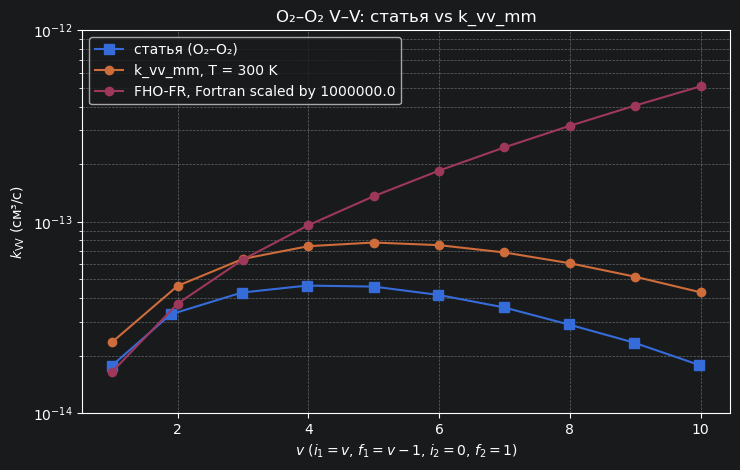

v 1 k_vv_mm 2.3571254260220107e-14 k_vv_fortran 1.6494429784953578e-08
v 2 k_vv_mm 4.628914578539174e-14 k_vv_fortran 3.738094818769028e-08
v 3 k_vv_mm 6.404510736925547e-14 k_vv_fortran 6.354387573319123e-08
v 4 k_vv_mm 7.462001381837785e-14 k_vv_fortran 9.60272274681745e-08
v 5 k_vv_mm 7.798029967497353e-14 k_vv_fortran 1.3606201691676435e-07
v 6 k_vv_mm 7.553034612007843e-14 k_vv_fortran 1.8509809055179542e-07
v 7 k_vv_mm 6.919318024111139e-14 k_vv_fortran 2.448412324294154e-07
v 8 k_vv_mm 6.077677846408459e-14 k_vv_fortran 3.1729639848927235e-07
v 9 k_vv_mm 5.168245806954851e-14 k_vv_fortran 4.0481807927290387e-07
v 10 k_vv_mm 4.2850234483997585e-14 k_vv_fortran 5.101689516085342e-07


In [7]:
from particles_data import O2
fortran_scale = 1e6
k_vv_fortran_O2 = np.array([k_vv_fhofer(O2, O2, i1=v-1, f1=v, i2=0, f2=1, T=300) for v in range(1, 11)])

k_mm_plot = np.where(k_from_mm > 0, k_from_mm, np.nan)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(
    x_FHO_FR_VV_O2_exp_art,
    y_FHO_FR_VV_O2_exp_art,
    "s-",
    ms=7,
    label="статья (O₂–O₂)",
)
ax.plot(
    v_int,
    k_mm_plot,
    "o-",
    ms=6,
    label=f"k_vv_mm, T = {T_O2_VV_plot} K",
)
ax.plot(v_int, k_vv_fortran_O2 * fortran_scale, 'o-', label=f'FHO-FR, Fortran scaled by {fortran_scale}')
ax.set_yscale("log")
ax.set_ylim(1e-14, 1e-12)
ax.set_xlabel(r"$v$ ($i_1=v$, $f_1=v-1$, $i_2=0$, $f_2=1$)")
ax.set_ylabel(r"$k_{\mathrm{VV}}$ (см³/с)")
ax.set_title("O₂–O₂ V–V: статья vs k_vv_mm")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

for v, k, k_fortran in zip(v_int, k_from_mm, k_vv_fortran_O2 * fortran_scale):
    print("v", int(v), "k_vv_mm", k, "k_vv_fortran", k_fortran * 1e6)

## Сравнение k_VV из расчетов, оригинальной статьи Адамовича для MM, статьи про эксперимент для N2-N2

In [5]:
import os
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
from concurrent.futures import ProcessPoolExecutor

from k_vv_mm import k_vv_mm_n2_n2_for_v
from particles_data import N2


calc_levels = [i for i in range(1, 10)]
T_calc = 300
_worker = partial(k_vv_mm_n2_n2_for_v, T=T_calc)

max_workers = min(len(calc_levels), os.cpu_count() or 8)
with ProcessPoolExecutor(max_workers=max_workers) as ex:
    k_vals = list(ex.map(_worker, calc_levels, chunksize=1))

for v, k in zip(calc_levels, k_vals):
    print("v", v, "k_vv_mm", k)
k_vv = np.array(k_vals)

x_fho_fr_exp_N2 = [1, 2, 3, 4, 5, 6, 7, 8, 9]
y_fho_fr_exp_N2 = [1.3779279812403515e-14, 2.467545635425734e-14, 3.1905635789785554e-14, 3.541369729185678e-14, 3.6418828106138156e-14, 3.5503914832419604e-14, 3.3400802855394945e-14, 3.071091936224292e-14, 2.766871247206691e-14]

x_FHO_FR_k_VV_MM_Adamovich_article = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y_FHO_FR_k_VV_MM_Adamovich_article = [1.0543589908346793e-14, 2.0433597178569395e-14, 3.039195382313195e-14, 3.5622478902624366e-14, 3.7558880906800835e-14, 3.657786820891425e-14, 3.4235979576075874e-14, 2.920903717032244e-14, 2.5252178500722037e-14, 2.1831343337815554e-14]


KeyboardInterrupt: 

In [8]:
fortran_scale = 1.5
k_vv_fortran = np.array([k_vv_fhofer(N2, N2, i1=1, i2=v - 1, f1=0, f2=v, T=300) for v in range(1, 10)])

plt.plot(x_fho_fr_exp_N2, y_fho_fr_exp_N2, label='FHO-FR, Exp N2 article')
plt.plot(x_FHO_FR_k_VV_MM_Adamovich_article, y_FHO_FR_k_VV_MM_Adamovich_article, label='FHO-FR, Adamovich MM article')
plt.plot(calc_levels, k_vv, 'o-', label='FHO-FR, calculated')
plt.plot(calc_levels, k_vv_fortran * fortran_scale, 'o-', label=f'FHO-FR, Fortran scaled by {fortran_scale}')
plt.yscale('log')
plt.xlabel('v + 1 (initial vibrational quantum of molecule 1)')
plt.ylabel('k (cm³/s)')
plt.ylim(5e-15, 1e-13)
plt.title('FHO-FR V-V rates for N₂–N₂ at T = 300 K (analytic formula (7))')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend()
plt.show()

NameError: name 'x_fho_fr_exp_N2' is not defined

In [6]:
import numpy as np
from scipy.special import factorial

# Физические константы
k_B = 1.380649e-23      # Дж/К
h = 6.62607015e-34      # Дж·с
c = 2.99792458e8        # м/с
hc_k = 1.4387769        # см·К  (для перевода см⁻¹ ↔ К)
amu = 1.660539e-27      # кг

# Параметры модели (строго по фортрану)
alpha_ang = 4.0         # Å⁻¹
alpha_SI = alpha_ang * 1e10   # м⁻¹
R0_fort = 2.52e-10      # фиксированное расстояние в м (≡ 2.52 Å)

def k_vv_fhofer(m1, m2, i1, f1, i2, f2, T):
    """
    Аналитическая скорость V-V перехода по FHO-FR (реализация fhovv).
    Возвращает коэффициент скорости в см³/с для экзотермического направления.
    """
    s = abs(i1 - f1)
    if s != abs(i2 - f2) or s == 0:
        raise ValueError("Переход не является V-V обменом одного порядка")

    # Приведённая масса столкновения
    mu = (m1.mass * m2.mass) / (m1.mass + m2.mass)

    # Энергии уровней в см⁻¹
    def E_cm(mol, v):
        return mol.ev_i[0][v] / (h * c * 100.0)

    E_i1 = E_cm(m1, i1); E_f1 = E_cm(m1, f1)
    E_i2 = E_cm(m2, i2); E_f2 = E_cm(m2, f2)

    delta_E_cm = (E_i1 + E_i2) - (E_f1 + E_f2)   # дефект в см⁻¹
    delta_E_K  = delta_E_cm * hc_k               # дефект в K

    if delta_E_cm < -1e-5:
        # эндотермическое направление: переворачиваем и применяем детальный баланс
        return k_vv_fhofer(m1, m2, f1, i1, f2, i2, T) * np.exp(-delta_E_K / T)

    # Средний колебательный квант перехода (см⁻¹)
    if i1 != f1:
        e1 = abs(E_i1 - E_f1) / s
    else:
        e1 = m1.we[0] - 2.0 * m1.wexe[0] * i1   # приближение как в фортране
    if i2 != f2:
        e2 = abs(E_i2 - E_f2) / s
    else:
        e2 = m2.we[0] - 2.0 * m2.wexe[0] * i2
    Evib_cm = (e1 + e2) / 2.0   # средняя частота перехода в см⁻¹

    # Угловая частота (рад/с)
    c_cm_per_s = c * 100.0      # скорость света в см/с
    omega_rad = 2.0 * np.pi * c_cm_per_s * Evib_cm   # рад/с

    # Безразмерный параметр ro2 = α² kT / (2 μ ω²)
    ro2 = alpha_SI**2 * k_B * T / (2.0 * mu * omega_rad**2)

    # Факториальные комбинации ns1, ns2
    def ns(v1, v2):
        return (factorial(max(v1, v2)) / factorial(min(v1, v2))) ** (1.0 / s)
    ns1 = ns(i1, f1)
    ns2 = ns(i2, f2)

    # Стерический фактор stfac (точно по фортрану)
    stfac  = (0.25 * (1.0 + 1.0 / 2.0**(s - 1))) ** 4
    stfac /= (s + 1)**2 * 2**s
    stfac *= factorial(s + 3) / 6.0

    # Нерезонансная поправка popc (воспроизведение формул fhovv)
    theta_prime = 4.0 * np.pi**2 * mu * omega_rad**2 / (alpha_SI**2 * k_B)
    arg = np.sqrt(theta_prime / T) * np.abs(delta_E_K / s) / (Evib_cm * hc_k) / np.sqrt(8.0)
    popc = np.exp(-2.0/3.0 * arg * 2.0/3.0)     # = exp(-4/9 * arg)
    popc = 0.5 * (3.0 - popc) * popc

    # Основная формула скорости (безразмерная)
    zompl0 = ns1 * ns2
    zompl1 = zompl0 * ro2
    zompl2 = stfac * zompl1 ** s / (factorial(s) ** 2)
    zompl3 = (1.0 + 2.0 * zompl1 / (s + 1.0) * stfac) ** (s + 4.0)
    rate_dimless = zompl2 / zompl3 * popc

    # Частота столкновений Z (как в фортране)
    mean_v = np.sqrt(8.0 * k_B * T / (np.pi * mu))          # средняя скорость, м/с
    sigma = np.pi * R0_fort**2                               # сечение, м²
    Z = 3.0 * sigma * mean_v                                 # м³/с

    # Результат в см³/с с симметризацией
    rate_cm3s = Z * 1e6 * rate_dimless * np.exp(0.5 * delta_E_K / T)
    return rate_cm3s